# Exploratory Data Analysis

## imports

In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

### importing raw data

In [94]:
train_df = pd.read_csv('../data/raw/cs-training.csv',delimiter=',')
test_df = pd.read_csv('../data/raw/cs-test.csv',delimiter=',')

### available columns in dataset

In [95]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

we want to get rid off column *Unnamed: 0* later

### class imbalance

<Axes: xlabel='SeriousDlqin2yrs', ylabel='count'>

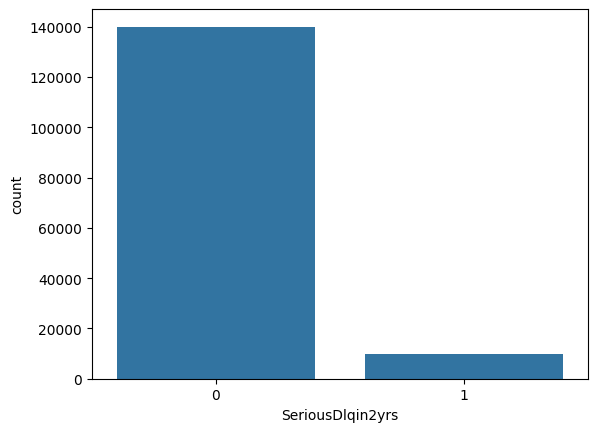

In [96]:
sns.countplot(x='SeriousDlqin2yrs', data=train_df)

**Huge class imbalance (93% / 7%)**

auc / gini is essential here

accurancy is useless as model would pick 0 and still get 93% accurancy - thats not what we are looking for

### Get MonthlyIncome/Age through barplot

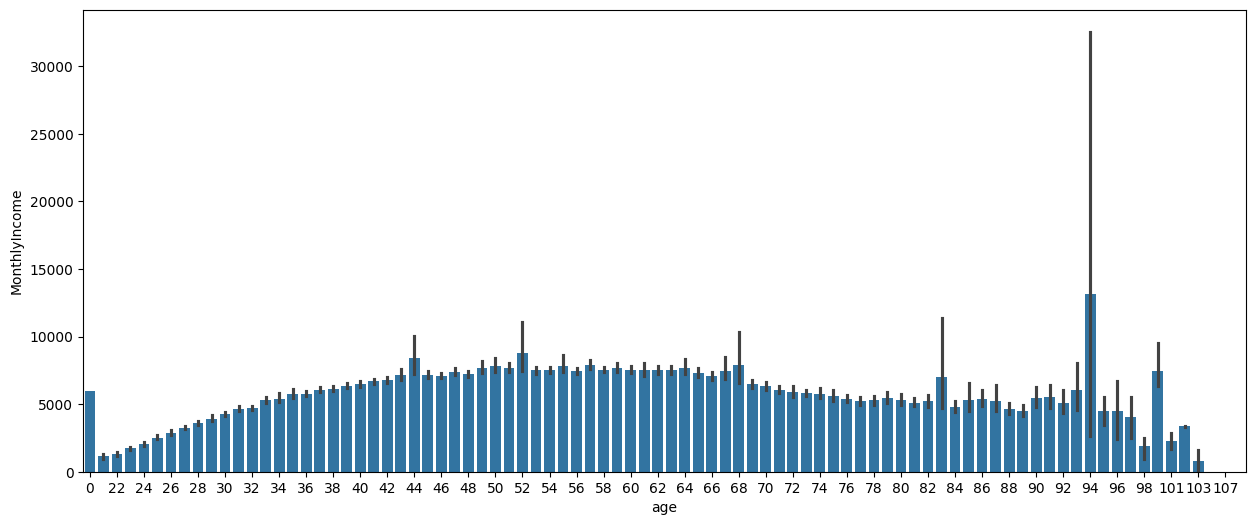

In [97]:
plt.figure(figsize=(15, 6))
ax = sns.barplot(data=train_df, x="age", y="MonthlyIncome", estimator=np.mean)
ax.xaxis.set_major_locator(MultipleLocator(2))
plt.show()

we can see that someone has 0 age and some income which is an **outliner** that we want to *get rid off later*

### outliners

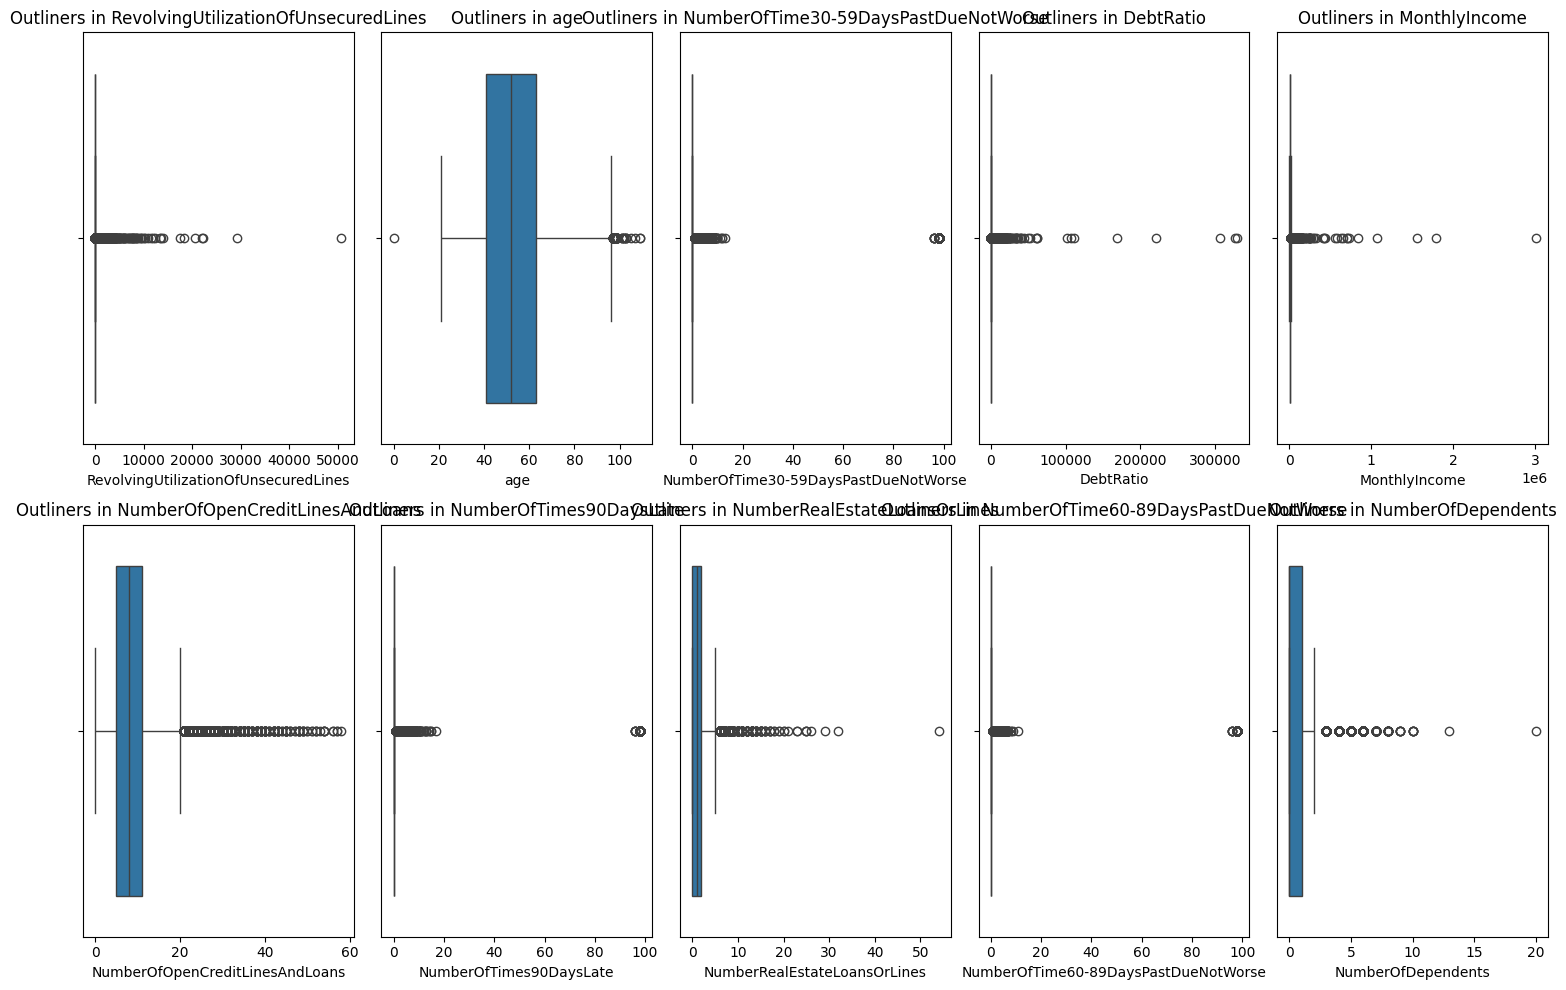

In [98]:
cols_to_check = ['RevolvingUtilizationOfUnsecuredLines', 'age',
'NumberOfTime30-59DaysPastDueNotWorse','DebtRatio', 'MonthlyIncome',
'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

plt.figure(figsize=(15,10))
for i, col in enumerate(cols_to_check, 1):
  plt.subplot(2,5,i)
  sns.boxplot(data=train_df, x=col)
  plt.title(f"Outliners in {col}")

plt.tight_layout()
plt.show()


we can see some outliners in our data such as:
<br />
<br />


| Column | Description | Action |
|---|---|---|
| `age` | age = 0 impossible | remove rows where age < 18 |
| `NumberOfTime30-59DaysPastDueNotWorse` | values ~96/98 are data errors | remove rows where value > 90 |
| `NumberOfTimes90DaysLate` | values ~96/98 are data errors | remove rows where value > 90 |
| `NumberOfTime60-89DaysPastDueNotWorse` | values ~96/98 are data errors | remove rows where value > 90 |
| `RevolvingUtilizationOfUnsecuredLines` | values > 10000% - impossible (utilization is a ratio) | cap at 1.0 or remove where value > 2 |
| `DebtRatio` | values 300k+ with no income - nonsens | remove or cap where MonthlyIncome = 0 and DebtRatio > 1 |

<br />
<br />


> **Note - columns considered valid (justified outliers):**

| Column | Justification |
|---|---|
| `MonthlyIncome` | 3M+ monthly - possible but extreme |
| `NumberOfOpenCreditLinesAndLoans` | 50+ credit lines/cards - rare but possible |
| `NumberRealEstateLoansOrLines` | Real estate investors may hold 10–20 |
| `NumberOfDependents` | 15+ dependents - extreme but biologically possible |

### Correlation heatmap

<Axes: >

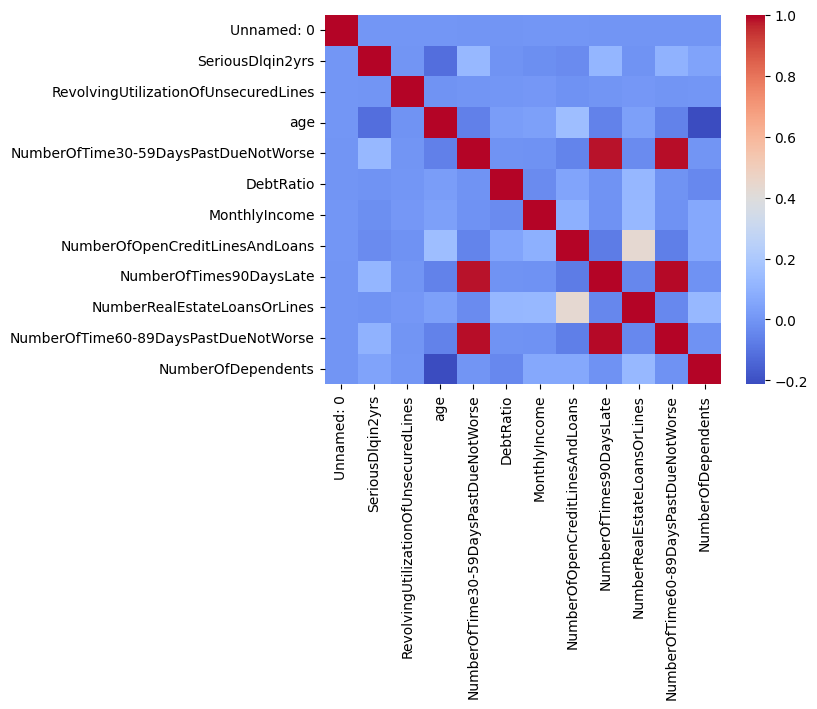

In [99]:
sns.heatmap(train_df.corr(), annot=False, cmap='coolwarm')

## Missing data

In [100]:
missing_percent_train = (train_df.isnull().sum() / len(train_df)) * 100
print(missing_percent_train[missing_percent_train>0])

MonthlyIncome         19.820667
NumberOfDependents     2.616000
dtype: float64


MonthlyIncome has 19.82% null values


NumberOfDependents has 2.62% null values


in both cases i'll use median to replace null values